MobileNetV2

Found 689 files belonging to 13 classes.
Train+Val size: 551
Test size: 138

===== FOLD 1 =====
Class Weights: {0: 1.0455840455840455, 1: 1.0857988165680474, 2: 0.941025641025641, 3: 1.1292307692307693, 4: 1.0857988165680474, 5: 1.1292307692307693, 6: 1.1292307692307693, 7: 0.9106699751861043, 8: 1.0857988165680474, 9: 1.4115384615384616, 10: 0.49527665317139, 11: 0.9734748010610079, 12: 1.4115384615384616}
Epoch 1/30
12/12 [==============================] - 6s 369ms/step - loss: 3.1647 - accuracy: 0.0872 - val_loss: 2.5967 - val_accuracy: 0.1359
Epoch 2/30
12/12 [==============================] - 4s 350ms/step - loss: 2.6167 - accuracy: 0.1662 - val_loss: 2.4260 - val_accuracy: 0.2283
Epoch 3/30
12/12 [==============================] - 4s 325ms/step - loss: 2.2116 - accuracy: 0.2561 - val_loss: 2.2699 - val_accuracy: 0.2826
Epoch 4/30
12/12 [==============================] - 4s 308ms/step - loss: 1.9214 - accuracy: 0.3597 - val_loss: 2.1450 - val_accuracy: 0.3207
Epoch 5/30
12/12 [===

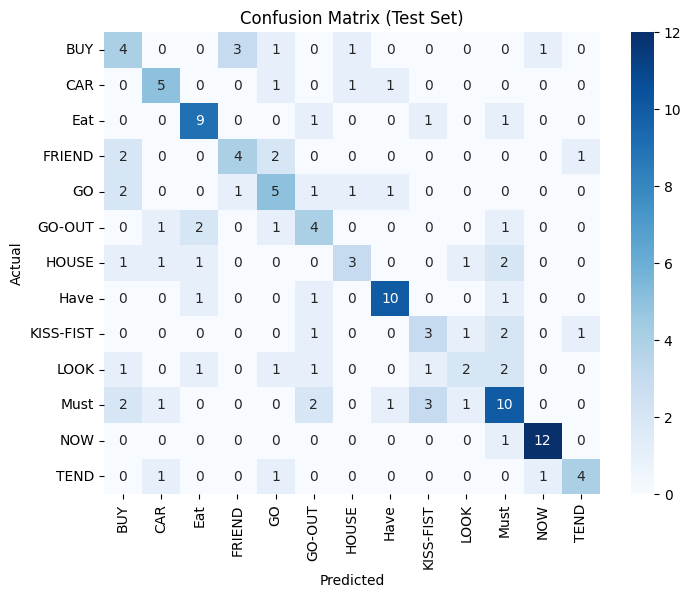

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import KFold, train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========================
# CONFIG
# ========================
DATA_PATH = "dataset_dynamic_full_cropped"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-3
K_FOLDS = 3

# ========================
# DATA AUGMENTATION
# ========================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal")
])

# ========================
# LOAD DATA
# ========================
def load_data():

    dataset = image_dataset_from_directory(
        DATA_PATH,
        image_size=IMG_SIZE,
        batch_size=None,
        shuffle=True
    )

    class_names = dataset.class_names
    num_classes = len(class_names)

    images = []
    labels = []

    for img, label in dataset:
        images.append(img.numpy())
        labels.append(label.numpy())

    images = np.array(images)
    labels = np.array(labels)

    # ========================
    # SPLIT TEST SET (20%)
    # ========================
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        images,
        labels,
        test_size=0.2,
        stratify=labels,
        random_state=42
    )

    print("Train+Val size:", len(X_trainval))
    print("Test size:", len(X_test))

    return X_trainval, X_test, y_trainval, y_test, num_classes, class_names


# ========================
# BUILD MODEL
# ========================
def build_model(num_classes):

    inputs = Input(shape=(224,224,3))

    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)

    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.001)
    )(x)

    model = Model(inputs, outputs)

    return model


# ========================
# PREPROCESS FUNCTION
# ========================
def preprocess_dataset(X, y, augment=False):

    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.map(
        lambda x, y: (preprocess_input(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds


# ========================
# MAIN
# ========================
if __name__ == "__main__":

    X_trainval, X_test, y_trainval, y_test, num_classes, class_names = load_data()

    kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

    fold_no = 1

    test_scores = []
    train_scores = []
    val_scores = []

    for train_idx, val_idx in kfold.split(X_trainval):

        print(f"\n===== FOLD {fold_no} =====")

        X_train = X_trainval[train_idx]
        y_train = y_trainval[train_idx]

        X_val = X_trainval[val_idx]
        y_val = y_trainval[val_idx]

        # ========================
        # CLASS WEIGHTS
        # ========================
        class_weights_vals = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train),
            y=y_train
        )

        class_weights = dict(enumerate(class_weights_vals))

        print("Class Weights:", class_weights)

        train_ds = preprocess_dataset(X_train, y_train, augment=True)
        val_ds = preprocess_dataset(X_val, y_val)

        model = build_model(num_classes)

        # ========================
        # CALLBACKS
        # ========================
        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        checkpoint = ModelCheckpoint(
            f"mobilenet_fold_V8_{fold_no}.keras",
            monitor="val_accuracy",
            save_best_only=True
        )

        # ========================
        # COMPILE
        # ========================
        model.compile(
            optimizer=tf.keras.optimizers.Adam(LR),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        # ========================
        # TRAIN
        # ========================
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            class_weight=class_weights,
            callbacks=[early_stop, checkpoint]
        )

        # ========================
        # TRAIN ACCURACY
        # ========================
        train_acc = history.history["accuracy"][-1]
        train_scores.append(train_acc)

        print(f"Training Accuracy: {train_acc*100:.2f}%")

        # ========================
        # VALIDATION ACCURACY
        # ========================
        val_loss, val_acc = model.evaluate(val_ds)
        val_scores.append(val_acc)

        print(f"Validation Accuracy: {val_acc*100:.2f}%")

        # ========================
        # TEST EVALUATION
        # ========================
        test_ds = preprocess_dataset(X_test, y_test)

        test_loss, test_acc = model.evaluate(test_ds)
        print(f"Test Accuracy: {test_acc*100:.2f}%")

        test_scores.append(test_acc)

        fold_no += 1

    # ========================
    # FINAL RESULTS
    # ========================
    print("\n==============================")
    print("FINAL RESULTS")
    print("==============================")

    print("Train Accuracies:", train_scores)
    print("Validation Accuracies:", val_scores)
    print("Test Accuracies:", test_scores)

    print("\nAverage Training Accuracy:", np.mean(train_scores)*100)
    print("Average Validation Accuracy:", np.mean(val_scores)*100)
    print("Average Test Accuracy:", np.mean(test_scores)*100)

    # ========================
    # CONFUSION MATRIX
    # ========================
    test_ds = preprocess_dataset(X_test, y_test)

    y_true = []
    y_pred = []

    for images, labels in test_ds:

        predictions = model.predict(images)
        predictions = np.argmax(predictions, axis=1)

        y_pred.extend(predictions)
        y_true.extend(labels.numpy())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

In [15]:
pip install psutil pandas

Note: you may need to restart the kernel to use updated packages.


Found 689 files belonging to 13 classes.
Using 483 files for training.
Found 689 files belonging to 13 classes.
Using 206 files for validation.
Class Weights: {0: 0.9288461538461539, 1: 1.3269230769230769, 2: 0.9526627218934911, 3: 1.1258741258741258, 4: 0.9526627218934911, 5: 1.1258741258741258, 6: 1.1258741258741258, 7: 0.8640429338103757, 8: 1.4289940828402368, 9: 1.1985111662531018, 10: 0.5463800904977375, 11: 0.8640429338103757, 12: 1.376068376068376}

===== TRAINING =====
Epoch 1/30
31/31 [==============================] - 6s 145ms/step - loss: 3.0986 - accuracy: 0.1118 - val_loss: 2.4338 - val_accuracy: 0.1406
Epoch 2/30
31/31 [==============================] - 4s 117ms/step - loss: 2.2332 - accuracy: 0.2795 - val_loss: 2.0261 - val_accuracy: 0.3438
Epoch 3/30
31/31 [==============================] - 4s 137ms/step - loss: 1.7869 - accuracy: 0.3975 - val_loss: 1.7635 - val_accuracy: 0.4688
Epoch 4/30
31/31 [==============================] - 4s 142ms/step - loss: 1.4490 - accuracy

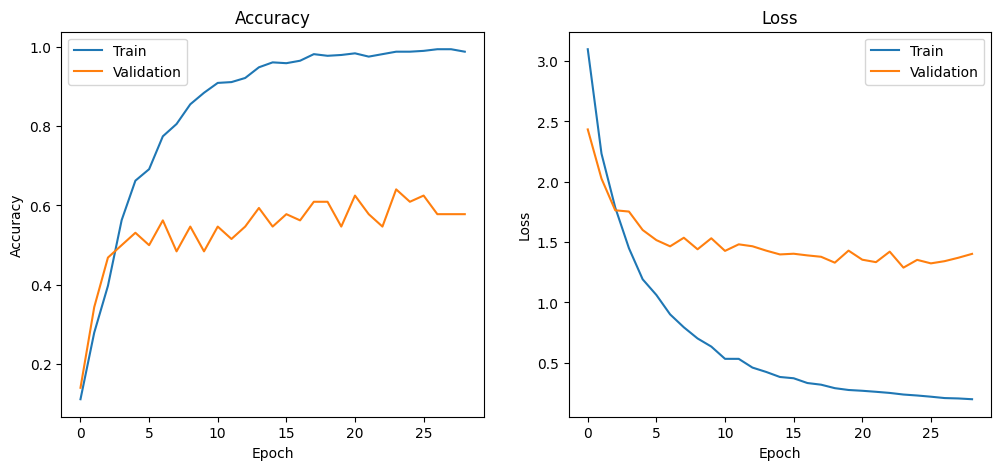

1/1 [==============================] - 0s 109ms/step


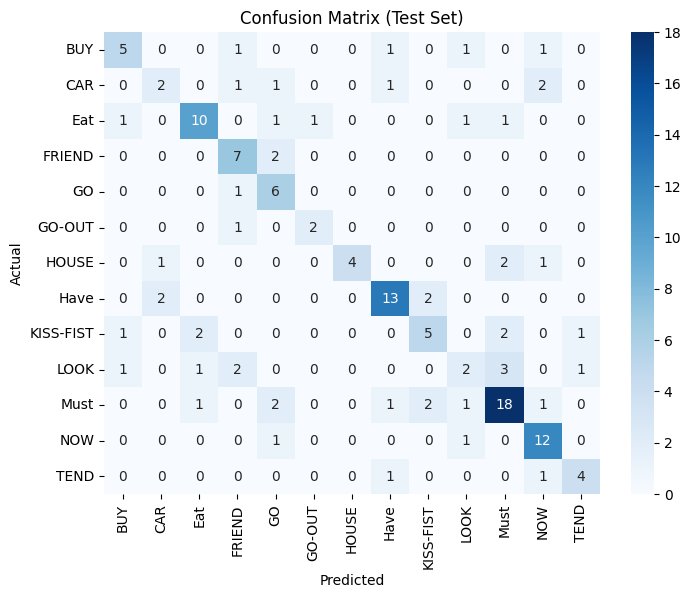

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========================
# CONFIG
# ========================
DATA_PATH = "dataset_dynamic_full_cropped"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-3

# ========================
# DATA AUGMENTATION
# ========================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal")
])

# ========================
# LOAD DATA
# ========================
def load_data():

    # -------- TRAIN (70%) --------
    train_ds = image_dataset_from_directory(
        DATA_PATH,
        validation_split=0.3,
        subset="training",
        seed=123,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    # -------- TEMP (30%) --------
    temp_ds = image_dataset_from_directory(
        DATA_PATH,
        validation_split=0.3,
        subset="validation",
        seed=123,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)

    # -------- SPLIT TEMP INTO VAL + TEST --------
    temp_batches = tf.data.experimental.cardinality(temp_ds)
    val_size = temp_batches // 3

    val_ds = temp_ds.take(val_size)
    test_ds = temp_ds.skip(val_size)

    # ========================
    # CLASS WEIGHTS
    # ========================
    y_train = []

    for _, label in train_ds.unbatch():
        y_train.append(label.numpy())

    y_train = np.array(y_train)

    class_weights_vals = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = dict(enumerate(class_weights_vals))

    print("Class Weights:", class_weights)

    AUTOTUNE = tf.data.AUTOTUNE

    # -------- TRAIN AUGMENTATION --------
    train_ds = train_ds.map(
        lambda x, y: (data_augmentation(x, training=True), y),
        num_parallel_calls=AUTOTUNE
    )

    train_ds = train_ds.map(
        lambda x, y: (preprocess_input(x), y),
        num_parallel_calls=AUTOTUNE
    )

    val_ds = val_ds.map(
        lambda x, y: (preprocess_input(x), y),
        num_parallel_calls=AUTOTUNE
    )

    test_ds = test_ds.map(
        lambda x, y: (preprocess_input(x), y),
        num_parallel_calls=AUTOTUNE
    )

    train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
    val_ds = val_ds.cache().prefetch(AUTOTUNE)
    test_ds = test_ds.cache().prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds, num_classes, class_weights, class_names


# ========================
# BUILD MODEL
# ========================
def build_model(num_classes):

    inputs = Input(shape=(224,224,3))

    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)

    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.001)
    )(x)

    model = Model(inputs, outputs)

    return model


# ========================
# MAIN
# ========================
if __name__ == "__main__":

    train_ds, val_ds, test_ds, num_classes, class_weights, class_names = load_data()

    model = build_model(num_classes)

    # ========================
    # CALLBACKS
    # ========================
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        "best_mobilenet_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )

    # ========================
    # COMPILE
    # ========================
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # ========================
    # TRAIN
    # ========================
    print("\n===== TRAINING =====")

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[early_stop, checkpoint]
    )

    # ========================
    # TRAINING ACCURACY
    # ========================
    train_acc = history.history["accuracy"][-1]
    print(f"\nTraining Accuracy: {train_acc*100:.2f}%")

    # ========================
    # VALIDATION EVALUATION
    # ========================
    val_loss, val_acc = model.evaluate(val_ds)
    print(f"\nValidation Accuracy: {val_acc*100:.2f}%")

    # ========================
    # TEST EVALUATION
    # ========================
    test_loss, test_acc = model.evaluate(test_ds)
    print(f"\nTest Accuracy: {test_acc*100:.2f}%")

    model.save(f"final_mobilenet_model_final, {test_acc*100:.2f}.keras")

    # ========================
    # TRAINING GRAPH
    # ========================
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train","Validation"])

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train","Validation"])

    plt.show()

    # ========================
    # CONFUSION MATRIX (TEST)
    # ========================
    y_true = []
    y_pred = []

    for images, labels in test_ds:

        predictions = model.predict(images)
        predictions = np.argmax(predictions, axis=1)

        y_pred.extend(predictions)
        y_true.extend(labels.numpy())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

EffecientNet_b0

Using: cpu
Classes: ['BUY', 'CAR', 'Eat', 'FRIEND', 'GO', 'GO-OUT', 'HOUSE', 'Have', 'KISS-FIST', 'LOOK', 'Must', 'NOW', 'TEND']
Total images: 689
Train: 482
Val: 137
Test: 70


Epoch 1: 100%|██████████| 31/31 [00:07<00:00,  3.93it/s]


Epoch 1: Train Acc = 0.1411 | Val Acc = 0.2044


Epoch 2: 100%|██████████| 31/31 [00:07<00:00,  4.01it/s]


Epoch 2: Train Acc = 0.3299 | Val Acc = 0.2774


...

Epoch 28: Train Acc = 0.9689 | Val Acc = 0.5547


Epoch 29: 100%|██████████| 31/31 [00:08<00:00,  3.63it/s]


Epoch 29: Train Acc = 0.9689 | Val Acc = 0.5328


Epoch 30: 100%|██████████| 31/31 [00:08<00:00,  3.67it/s]


Epoch 30: Train Acc = 0.9689 | Val Acc = 0.5182
 Early stopping


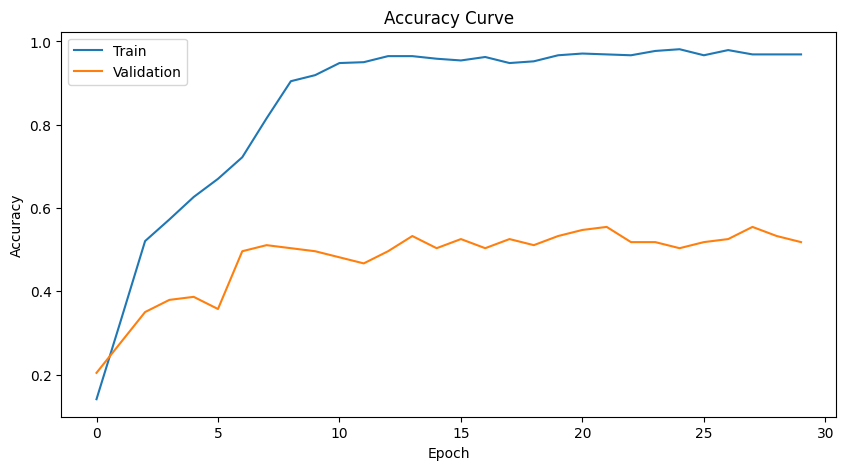


 Test Accuracy: 0.5714285714285714
 Model saved as: efficientnet_0.5714.pth

Classification Report:

              precision    recall  f1-score   support

         BUY       0.33      0.25      0.29         4
         CAR       0.60      0.75      0.67         4
         Eat       0.55      0.67      0.60         9
      FRIEND       1.00      1.00      1.00         4
          GO       0.33      0.50      0.40         4
      GO-OUT       1.00      1.00      1.00         2
       HOUSE       0.60      0.43      0.50         7
        Have       0.67      0.29      0.40         7
   KISS-FIST       0.50      0.20      0.29         5
        LOOK       0.00      0.00      0.00         4
        Must       0.50      0.80      0.62        10
         NOW       0.67      1.00      0.80         6
        TEND       0.67      0.50      0.57         4

    accuracy                           0.57        70
   macro avg       0.57      0.57      0.55        70
weighted avg       0.56      0.5

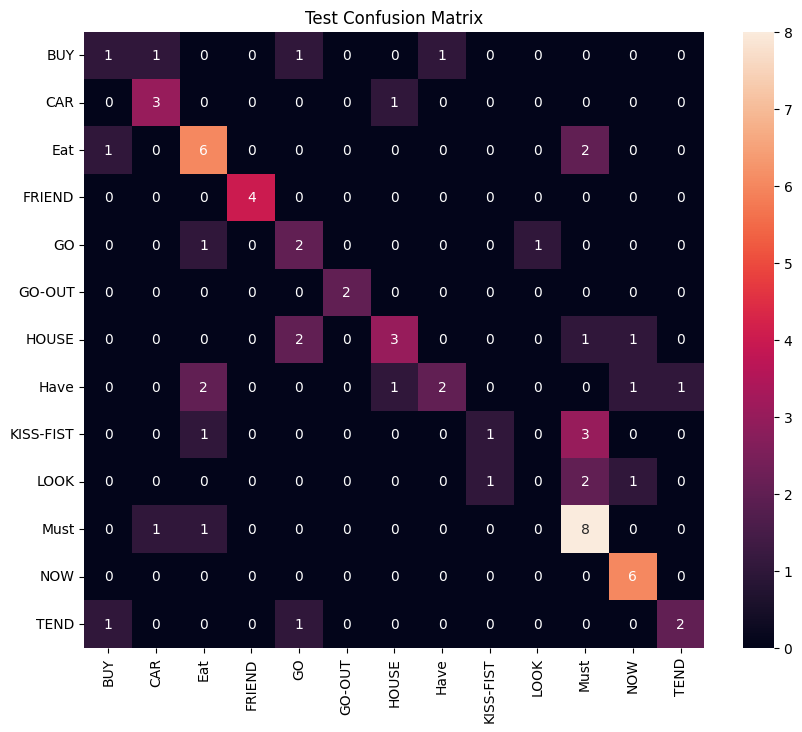


 FINAL RESULTS
Final Training Accuracy: 0.9689
Best Validation Accuracy: 0.5547
Test Accuracy: 0.5714


In [9]:
# ============================================================
# IMPORTS
# ============================================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# CONFIG
# ============================================================
DATASET_PATH = "dataset_dynamic_full_cropped"
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-3
PATIENCE = 8

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

# ============================================================
# TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip()
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ============================================================
# LOAD DATASET
# ============================================================
full_dataset = datasets.ImageFolder(DATASET_PATH, transform=train_transform)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Total images:", len(full_dataset))

# ============================================================
# SPLIT DATA (70 / 15 / 15)
# ============================================================
train_size = int(0.7 * len(full_dataset))
val_size   = int(0.2 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train:", train_size)
print("Val:", val_size)
print("Test:", test_size)

# ============================================================
# MODEL (EfficientNet-B0)
# ============================================================
model = timm.create_model("efficientnet_b0", pretrained=True)

# Freeze most layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
in_features = model.get_classifier().in_features
model.classifier = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Dropout(0.6),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

# ============================================================
# LOSS + OPTIMIZER
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ============================================================
# TRAINING LOOP
# ============================================================
best_val_acc = 0
patience_counter = 0

train_acc_history = []
val_acc_history = []

for epoch in range(EPOCHS):

    # ---------- TRAIN ----------
    model.train()
    train_correct, train_total = 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total

    # ---------- VALIDATION ----------
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    scheduler.step()

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f} | Val Acc = {val_acc:.4f}")

    # ---------- UNFREEZE LAST BLOCK ----------
    if epoch == 5:
        print(" Unfreezing last layers...")
        for name, param in model.named_parameters():
            if "blocks.6" in name or "blocks.7" in name:
                param.requires_grad = True

    # ---------- EARLY STOP ----------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_efficientnet.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(" Early stopping")
            break

# ============================================================
# PLOT ACCURACY
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(train_acc_history, label="Train")
plt.plot(val_acc_history, label="Validation")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# ============================================================
# TEST EVALUATION
# ============================================================
model.load_state_dict(torch.load("best_efficientnet.pth"))
model.eval()

test_correct, test_total = 0, 0
all_preds, all_true = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

test_acc = test_correct / test_total

print("\n Test Accuracy:", test_acc)

# ============================================================
# SAVE MODEL
# ============================================================
model_name = f"efficientnet_{test_acc:.4f}.pth"
torch.save(model.state_dict(), model_name)

print(f" Model saved as: {model_name}")

# ============================================================
# REPORT + CONFUSION MATRIX
# ============================================================
print("\nClassification Report:\n")
print(classification_report(all_true, all_preds, target_names=class_names))

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Test Confusion Matrix")
plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n FINAL RESULTS")
print(f"Final Training Accuracy: {train_acc_history[-1]:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

ResNet-18

Using: cpu
Classes: ['BUY', 'CAR', 'Eat', 'FRIEND', 'GO', 'GO-OUT', 'HOUSE', 'Have', 'KISS-FIST', 'LOOK', 'Must', 'NOW', 'TEND']
Total images: 689
Train: 482
Val: 137
Test: 70


Epoch 1: 100%|██████████| 31/31 [00:06<00:00,  4.61it/s]


Epoch 1: Train Acc = 0.1017 | Val Acc = 0.1606


Epoch 2: 100%|██████████| 31/31 [00:06<00:00,  4.51it/s]


Epoch 2: Train Acc = 0.2801 | Val Acc = 0.3212


...

Epoch 28: Train Acc = 0.9979 | Val Acc = 0.5401


Epoch 29: 100%|██████████| 31/31 [00:09<00:00,  3.12it/s]


Epoch 29: Train Acc = 0.9959 | Val Acc = 0.5255


Epoch 30: 100%|██████████| 31/31 [00:09<00:00,  3.13it/s]


Epoch 30: Train Acc = 0.9959 | Val Acc = 0.5328


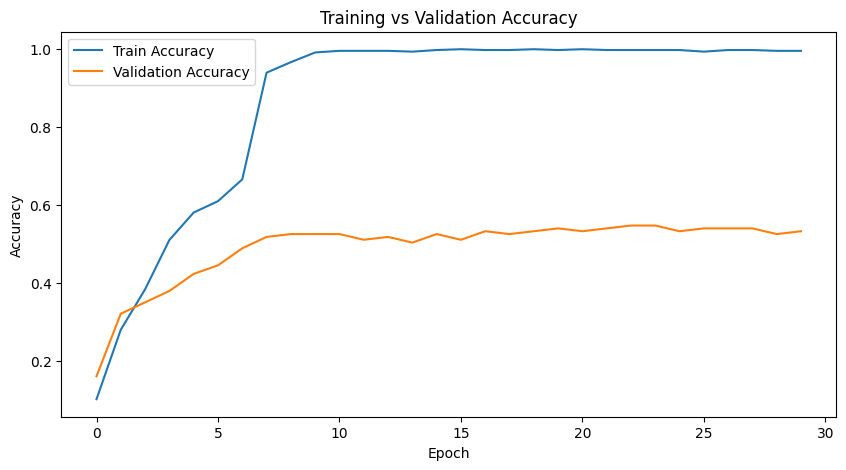


 Test Accuracy: 0.5428571428571428
 Model saved as: resnet18_0.5429.pth

Classification Report:

              precision    recall  f1-score   support

         BUY       0.60      0.75      0.67         4
         CAR       0.33      0.25      0.29         4
         Eat       0.60      0.67      0.63         9
      FRIEND       1.00      1.00      1.00         4
          GO       0.20      0.25      0.22         4
      GO-OUT       0.33      0.50      0.40         2
       HOUSE       1.00      0.43      0.60         7
        Have       0.60      0.43      0.50         7
   KISS-FIST       0.50      0.20      0.29         5
        LOOK       0.00      0.00      0.00         4
        Must       0.47      0.80      0.59        10
         NOW       0.50      0.83      0.62         6
        TEND       0.67      0.50      0.57         4

    accuracy                           0.54        70
   macro avg       0.52      0.51      0.49        70
weighted avg       0.55      0.54   

c:\Users\Kazumi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kazumi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Kazumi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

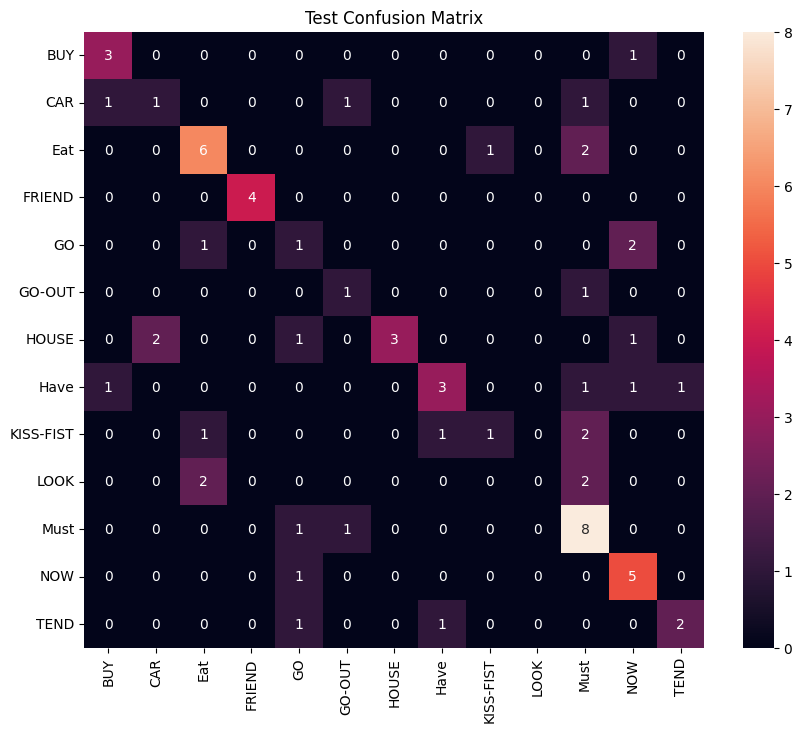


 FINAL RESULTS
Final Training Accuracy: 0.9959
Best Validation Accuracy: 0.5474
Test Accuracy: 0.5429


In [10]:
# ============================================================
# IMPORTS
# ============================================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# CONFIG
# ============================================================
DATASET_PATH = "dataset_dynamic_full_cropped"
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-3
PATIENCE = 8

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

# ============================================================
# TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip()
 
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ============================================================
# LOAD DATASET
# ============================================================
full_dataset = datasets.ImageFolder(DATASET_PATH, transform=train_transform)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Total images:", len(full_dataset))

# ============================================================
# SPLIT DATA (70 / 15 / 15)
# ============================================================
train_size = int(0.7 * len(full_dataset))
val_size   = int(0.2 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply transforms
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train:", train_size)
print("Val:", val_size)
print("Test:", test_size)

# ============================================================
# MODEL (ResNet18)
# ============================================================
model = timm.create_model("resnet18", pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
in_features = model.get_classifier().in_features
model.fc = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

# ============================================================
# LOSS + OPTIMIZER
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ============================================================
# TRAINING LOOP
# ============================================================
best_val_acc = 0
patience_counter = 0

train_acc_history = []
val_acc_history = []

for epoch in range(EPOCHS):

    # ---------- TRAIN ----------
    model.train()
    train_correct, train_total = 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total

    # ---------- VALIDATION ----------
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    scheduler.step()

    # store history
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f} | Val Acc = {val_acc:.4f}")

    # ---------- UNFREEZE LAST BLOCK ----------
    if epoch == 5:
        print("Unfreezing last layer...")
        for name, param in model.named_parameters():
            if "layer4" in name:
                param.requires_grad = True

    # ---------- EARLY STOP ----------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet18.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break

# ============================================================
# PLOT ACCURACY CURVE
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# ============================================================
# TEST EVALUATION
# ============================================================
model.load_state_dict(torch.load("best_resnet18.pth"))
model.eval()

test_correct, test_total = 0, 0
all_preds, all_true = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

test_acc = test_correct / test_total

print("\n Test Accuracy:", test_acc)

# ============================================================
# SAVE MODEL WITH ACCURACY
# ============================================================
model_name = f"resnet18_{test_acc:.4f}.pth"
torch.save(model.state_dict(), model_name)

print(f" Model saved as: {model_name}")

# ============================================================
# CONFUSION MATRIX + REPORT
# ============================================================
print("\nClassification Report:\n")
print(classification_report(all_true, all_preds, target_names=class_names))

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Test Confusion Matrix")
plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n FINAL RESULTS")
print(f"Final Training Accuracy: {train_acc_history[-1]:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")